# Amy Njenga - 668698
## Dsa 4060 week 1 lab

## Import Libraries

In [1]:
from pathlib import Path 
import pandas as pd 
import matplotlib.pyplot as plt 
pd.set_option('display.max_columns', None)

## Define File Paths

In [2]:
PROJECT_ROOT = Path('..') 
DATA_DIR = PROJECT_ROOT / 'data' 
IMAGES_DIR = PROJECT_ROOT / 'images' 
IMAGES_DIR.mkdir(exist_ok=True) 
MOVIES_FILE = DATA_DIR / 'movies.csv' 
RATINGS_FILE = DATA_DIR / 'ratings.csv'

## Loading the csvs

In [3]:
movies = pd.read_csv(MOVIES_FILE)
ratings = pd.read_csv(RATINGS_FILE)

print("movies shape:", movies.shape)
print("ratings shape:", ratings.shape)

movies shape: (9742, 3)
ratings shape: (100836, 4)


## Preview and Inspect

In [4]:
display(movies.head())
display(ratings.head())

print(movies.info())
print(ratings.info())


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None


## Validating the data

In [5]:
print("Missing values in movies:")
print(movies.isnull().sum())

print("Missing values in ratings:")
print(ratings.isnull().sum())

print("Duplicate rows in movies:", movies.duplicated().sum())
print("Duplicate rows in ratings:", ratings.duplicated().sum())

print("Ratings range:", ratings ['rating'].min(), "to", ratings['rating'].max())
print("Unknown movie Ids:", (~ratings['movieId'].isin(movies['movieId'])).sum())


Missing values in movies:
movieId    0
title      0
genres     0
dtype: int64
Missing values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
Duplicate rows in movies: 0
Duplicate rows in ratings: 0
Ratings range: 0.5 to 5.0
Unknown movie Ids: 0


There are no duplicated rows
There are no missing values either
This means that all movieids are unique and accounted for

## Summary of Interaction Data

In [6]:
n_users = ratings['userId'].nunique()
n_movies_rated = ratings ['movieId'].nunique()
n_Interactions = len(ratings)

print('Unique users:', n_users)
print('Movies with at least one rating: ', n_movies_rated)
print(ratings['rating'].describe())


Unique users: 610
Movies with at least one rating:  9724
count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


Mean: This is the average rating for all movies so we can expect 3.5 to be a movie that's just okay

Std: This is the standard devaition away from the mean for movie ratings, the deviation is small meaning the ratings all fall within a close range and there are no outlier ratings

Min: This is the minimum rating one can give a movie, it is 0.5 which can be inferred to mean the movie was bad or low quality

Max: This is the maximum rating one can give a movie, it is 5 meaning the movie was popular, well-liked and even high quality

The total number of movies in the csv is 9742 while the movies with at least one rating are 9724, this means that there are 18 movies that have no rating on the platform. This could mean those films are obscure or not widely available which results in a tiny audience and no ratings.

## Ratings per user and per movie

In [7]:
ratings_per_user = ratings.groupby('userId').size()
ratings_per_movies = ratings.groupby('movieId').size()

print("Ratings per user:")
print(ratings_per_user.describe())


print("ratings per movie: ")
print(ratings_per_movies.describe())



Ratings per user:
count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64
ratings per movie: 
count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
dtype: float64


## Examining ratings distribution

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64


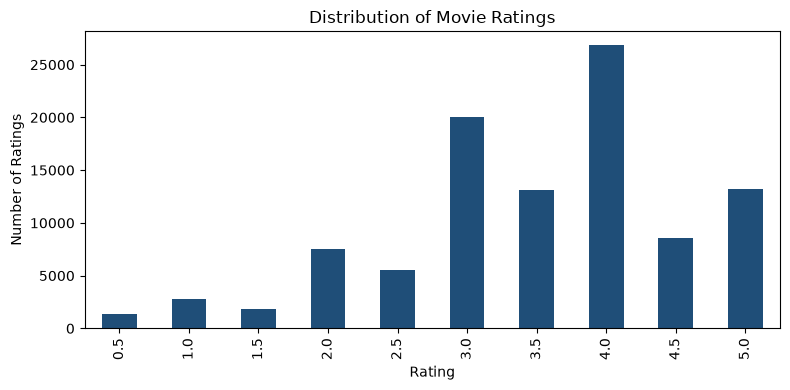

In [8]:
ratings_distribution = ratings['rating'].value_counts().sort_index()
print(ratings_distribution) 
ax = ratings_distribution.plot(kind='bar', color='#1F4E78', figsize=(8, 4)) 
ax.set_title('Distribution of Movie Ratings') 
ax.set_xlabel('Rating') 
ax.set_ylabel('Number of Ratings') 
plt.tight_layout() 
plt.show()

The 4.0 rating appears most often indicatng majority of users rate highly

The 0.5 rating appears the least indicating that very few movies are given a low rating

Low ratings in general are rare with majority of the weight leaning on the higher end of the distribution

This confirms our earlier finding of the average rating being around 3 to 3.5, the numbers do cluster around that area.




## Calculating Interaction Matrix Sparsity

In [9]:
possible_interactions = n_users * n_movies_rated 
observed_interactions = n_Interactions 
sparsity = 1 - (observed_interactions / possible_interactions) 
print(f'Possible interactions: {possible_interactions:,}') 
print(f'Observed interactions: {observed_interactions:,}') 
print(f'Sparsity: {sparsity:.2%}')

Possible interactions: 5,931,640
Observed interactions: 100,836
Sparsity: 98.30%


The calculated percentage is approximately 98% meaning that the interaction matrix is incredibly sparse with multiple movies missing ratings from users. Users only rate a small subset of movies. This then makes it difficult to infer a user's preference as they have not interacted will the full scope of possible movies. The information in the matrix only tells us what the user has rated and nothing about movies they MAY have seen but not rated.

## Building a Popularity Recommender

In [10]:
movie_stats = ( ratings.groupby('movieId') .agg(average_rating=('rating', 'mean'), rating_count=('rating', 'count')) .reset_index() ) 
movie_stats = movie_stats.merge( movies[['movieId', 'title', 'genres']], on='movieId', how='left', validate='one_to_one' ) 
display(movie_stats.head())

,movieId,average_rating,rating_count,title,genres
0,1,3.920930,215,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,3.431818,110,Jumanji (1995),Adventure|Children|Fantasy
2,3,3.259615,52,Grumpier Old Men (1995),Comedy|Romance
3,4,2.357143,7,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,3.071429,49,Father of the Bride Part II (1995),Comedy


## Highest Rated Movies

In [11]:
most_rated = ( movie_stats.sort_values( ['rating_count', 'average_rating'], ascending=[False, False] ) .head(10) ) 
display(most_rated[['title', 'rating_count', 'average_rating']])

,title,rating_count,average_rating
314,Forrest Gump (1994),329,4.164134
277,"Shawshank Redemption, The (1994)",317,4.429022
257,Pulp Fiction (1994),307,4.197068
510,"Silence of the Lambs, The (1991)",279,4.161290
1938,"Matrix, The (1999)",278,4.192446
224,Star Wars: Episode IV - A New Hope (1977),251,4.231076
418,Jurassic Park (1993),238,3.750000
97,Braveheart (1995),237,4.031646
507,Terminator 2: Judgment Day (1991),224,3.970982
461,Schindler's List (1993),220,4.225000


## Highest Average Rated

In [12]:
highest_average = ( movie_stats.sort_values( ['average_rating', 'rating_count'], ascending=[False, False] ) .head(10) )
display(highest_average[['title', 'rating_count', 'average_rating']])

,title,rating_count,average_rating
48,Lamerica (1994),2,5.0
87,Heidi Fleiss: Hollywood Madam (1995),2,5.0
869,Lesson Faust (1994),2,5.0
2593,Jonah Who Will Be 25 in the Year 2000 (Jonas q...,2,5.0
4384,Belle époque (1992),2,5.0
4583,Come and See (Idi i smotri) (1985),2,5.0
7347,Enter the Void (2009),2,5.0
121,"Awfully Big Adventure, An (1995)",1,5.0
405,Live Nude Girls (1995),1,5.0
432,In the Realm of the Senses (Ai no corrida) (1976),1,5.0


## Minimum ratings baseline

In [13]:
Min_ratings = 50 
popular_movies = ( movie_stats[movie_stats['rating_count'] >= Min_ratings] .sort_values( ['average_rating', 'rating_count'], ascending=[False, False] ) .head(10) ) 
display(popular_movies[['title', 'genres', 'rating_count', 'average_rating']])

,title,genres,rating_count,average_rating
277,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
659,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
974,Cool Hand Luke (1967),Drama,57,4.271930
602,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
686,Rear Window (1954),Mystery|Thriller,84,4.261905
921,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
6298,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336
913,Goodfellas (1990),Crime|Drama,126,4.250000
694,Casablanca (1942),Drama|Romance,100,4.240000


In [14]:
Min_ratings = 27 
popular_movies = ( movie_stats[movie_stats['rating_count'] >= Min_ratings] .sort_values( ['average_rating', 'rating_count'], ascending=[False, False] ) .head(10) ) 
display(popular_movies[['title', 'genres', 'rating_count', 'average_rating']])

,title,genres,rating_count,average_rating
277,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
704,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Drama|Film-Noir|Romance,27,4.333333
680,"Philadelphia Story, The (1940)",Comedy|Drama|Romance,29,4.310345
905,Lawrence of Arabia (1962),Adventure|Drama|War,45,4.300000
210,Hoop Dreams (1994),Documentary,29,4.293103
659,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
974,Cool Hand Luke (1967),Drama,57,4.271930
602,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
686,Rear Window (1954),Mystery|Thriller,84,4.261905


## Creation of a function based on logic

In [15]:
def recommend_popular_movies(stats, min_ratings=50, top_n=10): 
    candidates = stats[stats['rating_count'] >= min_ratings].copy() 
    return ( candidates.sort_values( 
        ['average_rating', 'rating_count'], 
        ascending=[False, False] 
        ) 
        .head(top_n) 
        [['movieId', 'title', 'genres', 'rating_count', 'average_rating']] 
        ) 
recommendations = recommend_popular_movies(movie_stats, 50, 10) 
display(recommendations)

,movieId,title,genres,rating_count,average_rating
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
659,858,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,2959,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
974,1276,Cool Hand Luke (1967),Drama,57,4.271930
602,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
686,904,Rear Window (1954),Mystery|Thriller,84,4.261905
921,1221,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
6298,48516,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336
913,1213,Goodfellas (1990),Crime|Drama,126,4.250000
694,912,Casablanca (1942),Drama|Romance,100,4.240000


# Build a weighted rating baseline

## Why use a weighted score

## Selection of the threshold

In [16]:
C = ratings['rating'].mean() 
m = movie_stats['rating_count'].quantile(0.90) 
print(f'Overall mean rating C: {C:.3f}') 
print(f'90th percentile rating count m: {m:.1f}')

Overall mean rating C: 3.502
90th percentile rating count m: 27.0


In [17]:
C = ratings['rating'].mean() 
m = movie_stats['rating_count'].quantile(0.70) 
print(f'Overall mean rating C: {C:.3f}') 
print(f'70th percentile rating count m: {m:.1f}')

Overall mean rating C: 3.502
70th percentile rating count m: 7.0


For the 90th percentile, only the top 10% of the of the range of rating count would quality, if we lower the percentile, then the top 30% would then qualify.

At the 90th, the cut off is 27 ratings or more so less movies would qualify.
At the 70th, the cut off is 7 ratings so more movies would qualify

Lowering the percentile increases the candidate pool, increasing the percentile lowers the candidate pool

## Calculating Weighted Scores

In [18]:
qualified = movie_stats[movie_stats['rating_count'] >= m].copy() 
v = qualified['rating_count'] 
R = qualified['average_rating']

qualified['weighted_score'] = ( (v / (v + m)) * R + (m / (v + m)) * C ) 
weighted_recommendations = ( qualified.sort_values( ['weighted_score', 'rating_count'], ascending=[False, False] ) .head(10) ) 
display(weighted_recommendations[[ 'title', 'genres', 'rating_count', 'average_rating', 'weighted_score' ]])

,title,genres,rating_count,average_rating,weighted_score
277,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022,4.408984
659,"Godfather, The (1972)",Crime|Drama,192,4.289062,4.261361
2224,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936,4.248937
840,"Streetcar Named Desire, A (1951)",Drama,20,4.475000,4.222626
921,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690,4.220668
602,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041,4.216451
46,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,204,4.237745,4.213322
224,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,251,4.231076,4.211283
913,Goodfellas (1990),Crime|Drama,126,4.250000,4.210608
6298,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336,4.206236


## Comaprison of lists

In [19]:
comparison = popular_movies[['title', 'rating_count', 'average_rating']].copy() 
comparison['method'] = 'Minimum 50 ratings' 
weighted_view = weighted_recommendations[[ 'title', 'rating_count', 'average_rating' ]].copy() 
weighted_view['method'] = 'Weighted score' 
display(pd.concat([comparison, weighted_view], ignore_index=True))

,title,rating_count,average_rating,method
0,"Shawshank Redemption, The (1994)",317,4.429022,Minimum 50 ratings
1,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),27,4.333333,Minimum 50 ratings
2,"Philadelphia Story, The (1940)",29,4.310345,Minimum 50 ratings
3,Lawrence of Arabia (1962),45,4.300000,Minimum 50 ratings
4,Hoop Dreams (1994),29,4.293103,Minimum 50 ratings
5,"Godfather, The (1972)",192,4.289062,Minimum 50 ratings
6,Fight Club (1999),218,4.272936,Minimum 50 ratings
7,Cool Hand Luke (1967),57,4.271930,Minimum 50 ratings
8,Dr. Strangelove or: How I Learned to Stop Worr...,97,4.268041,Minimum 50 ratings
9,Rear Window (1954),84,4.261905,Minimum 50 ratings


Shawshank Redemption, The (1994), Godfather, The (1972), Fight Club (1999) appear in both lists. This means it is safe to conclude that the movies are both popular and highly rated so they may appeal to the average viewr.

The weighted score method is more conservative about small rating counts this is because it is hesitant to exclude those movies just because they have a smaller amount of ratings. 

The minimum threshold method is harsh about inclusion with a strict cut off while the weighted score method still includes movies with low ratings but reduces their influence on the overall mean.



## Visualisation and testing output

## Creation of a top 10 chart

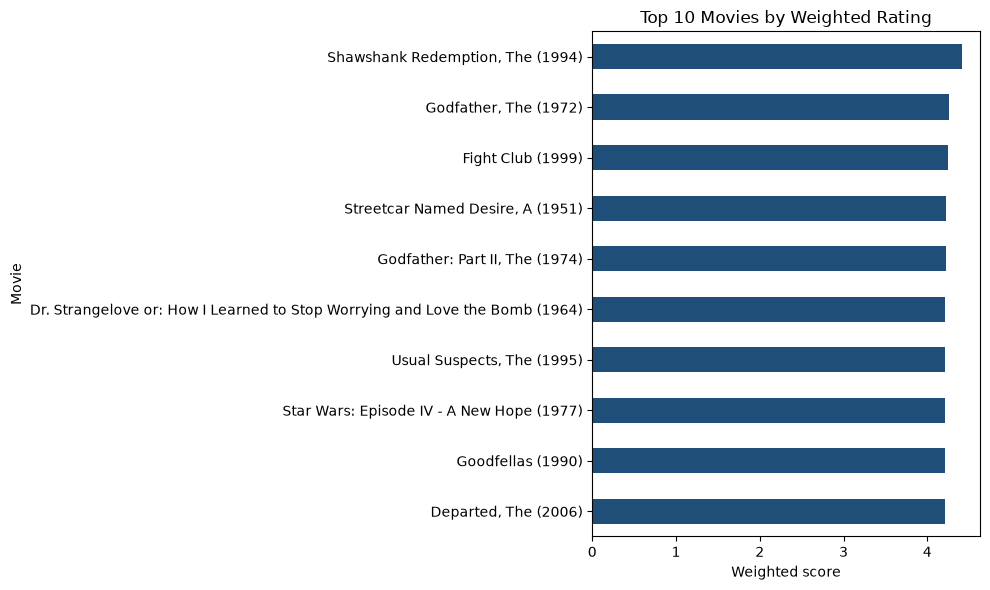

In [20]:
plot_data = weighted_recommendations.sort_values('weighted_score') 
ax = plot_data.plot( x='title', y='weighted_score', kind='barh', figsize=(10, 6), color='#1F4E78', legend=False ) 
ax.set_title('Top 10 Movies by Weighted Rating') 
ax.set_xlabel('Weighted score') 
ax.set_ylabel('Movie') 
plt.tight_layout() 
plt.savefig(IMAGES_DIR / 'top10_recommendations.png', dpi=150, bbox_inches='tight') 
plt.show()

## Basic Tests

In [21]:
assert len(recommendations) <= 10 
assert recommendations['movieId'].is_unique 
assert recommendations['rating_count'].ge(50).all() 
assert recommendations['average_rating'].between(0.5, 5.0).all() 
assert recommendations['title'].notna().all() 
assert len(weighted_recommendations) <= 10 
assert weighted_recommendations['weighted_score'].notna().all() 
print('All checks passed.')

All checks passed.


## The trial with different parametres

In [22]:
display(recommend_popular_movies(movie_stats, min_ratings=20, top_n=5)) 
display(recommend_popular_movies(movie_stats, min_ratings=100, top_n=5))

,movieId,title,genres,rating_count,average_rating
840,1104,"Streetcar Named Desire, A (1951)",Drama,20,4.475000
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
704,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Drama|Film-Noir|Romance,27,4.333333
680,898,"Philadelphia Story, The (1940)",Comedy|Drama|Romance,29,4.310345
905,1204,Lawrence of Arabia (1962),Adventure|Drama|War,45,4.300000


,movieId,title,genres,rating_count,average_rating
277,318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022
659,858,"Godfather, The (1972)",Crime|Drama,192,4.289062
2224,2959,Fight Club (1999),Action|Crime|Drama|Thriller,218,4.272936
921,1221,"Godfather: Part II, The (1974)",Crime|Drama,129,4.259690
6298,48516,"Departed, The (2006)",Crime|Drama|Thriller,107,4.252336


The lower threshold does admit more rankings but it makes the average rating subject to influence from that low count.

A higher threshold would ensure that the average rating is not inflated by using a higher amount of ratings.

## Use of a genre filter

In [23]:
def recommend_by_genre(stats, genre, min_ratings=30, top_n=10): 
    mask = stats['genres'].str.contains(genre, case=False, na=False) 
    return recommend_popular_movies(stats[mask], min_ratings, top_n)
    

In [24]:
display(recommend_by_genre(movie_stats, 'Comedy', 30, 10))

,movieId,title,genres,rating_count,average_rating
602,750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,97,4.268041
898,1197,"Princess Bride, The (1987)",Action|Adventure|Comedy|Fantasy|Romance,142,4.232394
257,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068
3617,4973,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",Comedy|Romance,120,4.183333
314,356,Forrest Gump (1994),Comedy|Drama|Romance|War,329,4.164134
862,1136,Monty Python and the Holy Grail (1975),Adventure|Comedy|Fantasy,136,4.161765
6659,57669,In Bruges (2008),Comedy|Crime|Drama|Thriller,41,4.158537
2992,4011,Snatch (2000),Comedy|Crime|Thriller,93,4.155914
1729,2324,Life Is Beautiful (La Vita è bella) (1997),Comedy|Drama|Romance|War,88,4.147727
520,608,Fargo (1996),Comedy|Crime|Drama|Thriller,181,4.116022


## Part 8 Interpret the Results
### 8.1 Questions for the Notebook
1. Which movie received the most ratings, and what was its average rating?

Forrest Gump (1994)	received the most ratings with a count of 329 and an average rating of 4.164133738601824

2. Which movie ranked first after applying the 50-rating threshold?

Shawshank Redemption (1994)	ranked first applying the 50-rating threshold with a count of 317 and and average rating of	4.429022082018927

3. Which movie ranked first using the weighted score?

Shawshank Redemption (1994)	ranked first using rated score with a count of 317 an average rating of	4.429022082018927 and a weighted score of 4.4089842558188845

4. How many movies qualified under the 90th-percentile threshold?

The threshold was 27 ratings so only 10 movies qualified

5. What changed when the minimum rating threshold was increased?

When the minimum rating threshold was increased, less movies qualified for the list

6. Why is the resulting list not personalized?

This is because it treats all users as the same and only accounts for average rating and rating count, these both collapse all users into one number

7. What bias may result from recommending only already-popular movies?

This may bias the recommender towards box office movies or blockbusters that have been highly marketed for a long period of time. This may fail to include newer movies or movies by smaller studios, lesser-known actors etc.

8. How could the system handle a new movie with no ratings?

The system could mitigate this by assigning the new movie with default values such as the average rating then seeing how it performs when it appears on the lists.





## Findings and Limitations



The main dataset included one sheet with all users and the movies they had rated, the other included all the movies and their average ratings. The matrix is then created by matching each movie with a user by its ratings. The ranking methods employ different assumptions when it comes to detrmining the most popular movies. Some methods use the highest average ratings which would fail to consider the inflated rating from movies with low ratings counts. Other ranking methods used the highest rating counts then sorting by average ratings which would output films that have both a wide audience and a high rating. The next ranking method makes use of a weighted score which includes all films in the calculation but penalises movies with low rating counts then outputing films which meet both criteria. The final method gives a richer ranked list of movies that mitigates certain problems but the list itself is not personalised and fails to consider new movies in the industry. This method also struggles when it comes to obscure movies with no ratings, indicating a cold start limitation. This method also fails to account for a users changing preference over time, eg. they may begin to prefer romance movies but increasingly get recommended action movies because that is what's popular. This method also fails to consider genre or the year of creation or the director of the film or the gross income. Ratings are increasingly uninformative because it does not indicate why a user chose to rate highly. It may have been the acting, the dialogue, the musical score, the style etc.

## Recommended improvements from the notes

• Use genres or textual features to build a content-based model.

• Use user-rating patterns to build collaborative filtering.

• Separate training and test data and evaluate recommendation quality.

• Add diversity, novelty, and coverage measures rather than optimizing only rating score.

• Consider time and recency because preferences and popularity can change.